# Phase 2: Customer Analytics

This notebook analyses Olist's customer base across three dimensions:

1. **RFM Segmentation**: grouping customers by recency, frequency, and monetary value into 8 actionable segments
2. **Historic CLV**: quantifying lifetime value by segment and identifying revenue concentration
3. **Cohort Retention**: assessing whether retention is structural or deteriorating over time

**Source:** `fact_orders` table in MySQL (~110K rows at order-item grain, filtered to delivered orders)

**Output produced:**
- `dim_customer_rfm` in MySQL: 93,358 customers with RFM and segment assignments
- `dim_customer_rfm_clv` in MySQL: RFM table enriched with historic CLV
- `agg_segment_clv` in MySQL: 8-segment summary for dashboard use
- `agg_cohort_retention` and `agg_cohort_sizes` in MySQL: retention matrices

**Key findings:**
- "Cannot Lose Them" segment (15.5% of customers) drives 29% of revenue, with revenue index 1.9x
- Top 20% of customers contribute 50-55% of total revenue (moderate concentration)
- Month-1 retention on meaningful cohorts (≥500 customers) is ~0.5%
- Retention is structurally low across all cohorts, not deteriorating

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
%matplotlib inline

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11

In [3]:
import os

USER = 'root'
PASSWORD = os.getenv('MYSQL_PASSWORD', 'YOUR_PASSWORD')
HOST = 'localhost'
PORT = 3306
DB = 'olist'

engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')
print('Engine created')

Engine created


In [4]:
fact = pd.read_sql('SELECT * FROM fact_orders', engine)
print(f"Loaded {len(fact):,} rows")
print(f"Distinct orders: {fact['order_id'].nunique():,}")
print(f"Distinct customers: {fact['customer_unique_id'].nunique():,}")
print(f"Date range: {fact['order_purchase_timestamp'].min().date()} → {fact['order_purchase_timestamp'].max().date()}")

Loaded 110,197 rows
Distinct orders: 96,478
Distinct customers: 93,358
Date range: 2016-09-15 → 2018-08-29


## Section 1: RFM Segmentation

Recency, Frequency, Monetary scoring assigns each customer a segment based on their purchase behaviour. Recency and Monetary use standard quintile binning via `qcut`. Frequency uses rule-based scoring because 96% of Olist customers have frequency = 1, which would break a quintile approach. 

Segment definitions are deterministic: a customer with R≥4, F≥4, and M≥4 is a "Champion", and so on. The 8 resulting segments map to standard retail marketing actions.

In [5]:
reference_date = fact['order_purchase_timestamp'].max() + timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

order_level = fact.groupby(['order_id', 'customer_unique_id'], as_index=False).agg(
    order_date = ('order_purchase_timestamp', 'first'), 
    order_value = ('total_payment_value', 'first'))
print(f'\nOrders aggregated: {len(order_level):,}')

rfm = order_level.groupby('customer_unique_id', as_index=False).agg(
    recency=('order_date', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('order_value', 'sum'))

print(f'Customers in RFM table: {len(rfm):,}')
print('\nFirst 5 rows:')
print(rfm.head())
print('\nSummary statistics:')
print(rfm.describe())

Reference date: 2018-08-30

Orders aggregated: 96,478
Customers in RFM table: 93,358

First 5 rows:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89

Summary statistics:
            recency     frequency      monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    165.197003
std      152.591453      0.209097    226.314012
min        1.000000      1.000000      0.000000
25%      114.000000      1.000000     63.052500
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.557500
max      714.000000     15.000000  13664.080000


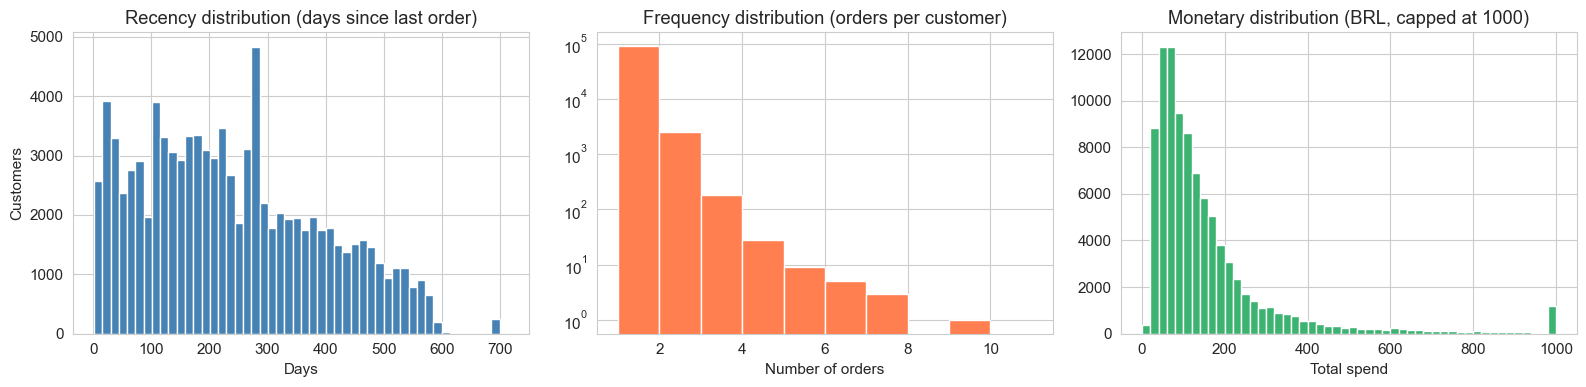


Frequency distribution:
frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Recency
axes[0].hist(rfm['recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency distribution (days since last order)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Customers')

#Frequency
axes[1].hist(rfm['frequency'], bins=range(1,12), color='coral', edgecolor='white')
axes[1].set_title('Frequency distribution (orders per customer)')
axes[1].set_xlabel('Number of orders')
axes[1].set_yscale('log')

#Monetary
axes[2].hist(rfm['monetary'].clip(upper=1000), bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Monetary distribution (BRL, capped at 1000)')
axes[2].set_xlabel('Total spend')

plt.tight_layout()
plt.show()

print('\nFrequency distribution:')
print(rfm['frequency'].value_counts().head(10))

In [7]:
rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

def score_frequency(f):
    if f == 1: return 1
    elif f == 2: return 3
    elif f == 3: return 4
    else: return 5

rfm['F'] = rfm['frequency'].apply(score_frequency)

rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print(rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'R', 'F', 'M', 'RFM_score']].head(10))

                 customer_unique_id  recency  frequency  monetary  R  F  M  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90  4  1  4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19  4  1  1   
2  0000f46a3911fa3c0805444483337064      537          1     86.22  1  1  2   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62  2  1  1   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89  2  1  4   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98  4  1  4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38  4  1  1   
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18  3  1  5   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12  1  1  4   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76  4  1  3   

  RFM_score  
0       414  
1       411  
2       112  
3       211  
4       214  
5       414  
6       411  
7       315  
8       114  
9

In [8]:
def assign_segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4:
        return 'Loyal Customers'
    elif r <= 2 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r >= 4 and f ==1:
        return 'New Customers'
    elif r >= 3 and m >= 3:
        return 'Promising'
    elif r <= 2:
        return 'Hibernating'
    else: 
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['segment'].value_counts())

segment
New Customers       36224
Hibernating         22489
Cannot Lose Them    14428
Promising           12127
Needs Attention      7632
At Risk               230
Champions             117
Loyal Customers       111
Name: count, dtype: int64


In [9]:
segment_summary = rfm.groupby('segment').agg(
    customers = ('customer_unique_id', 'count'),
    avg_recency = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'), 
    avg_monetary = ('monetary', 'mean'),
    total_revenue = ('monetary', 'sum')). round(1).sort_values('total_revenue', ascending=False)

segment_summary['pct_customers'] = (segment_summary['customers'] / segment_summary['customers'].sum() * 100).round(1)
segment_summary['pct_revenue'] = (segment_summary['total_revenue']/segment_summary['total_revenue'].sum() * 100).round(1)

print(segment_summary)

                  customers  avg_recency  avg_frequency  avg_monetary  \
segment                                                                 
New Customers         36224         90.6            1.0         164.3   
Cannot Lose Them      14428        393.5            1.0         309.6   
Promising             12127        209.8            1.1         231.9   
Hibernating           22489        396.1            1.0          72.7   
Needs Attention        7632        218.4            1.0          54.6   
Champions               117         91.4            3.5         572.6   
Loyal Customers         111        319.1            3.2         437.5   
At Risk                 230        382.5            2.0          98.0   

                  total_revenue  pct_customers  pct_revenue  
segment                                                      
New Customers         5953007.7           38.8         38.6  
Cannot Lose Them      4466878.6           15.5         29.0  
Promising            

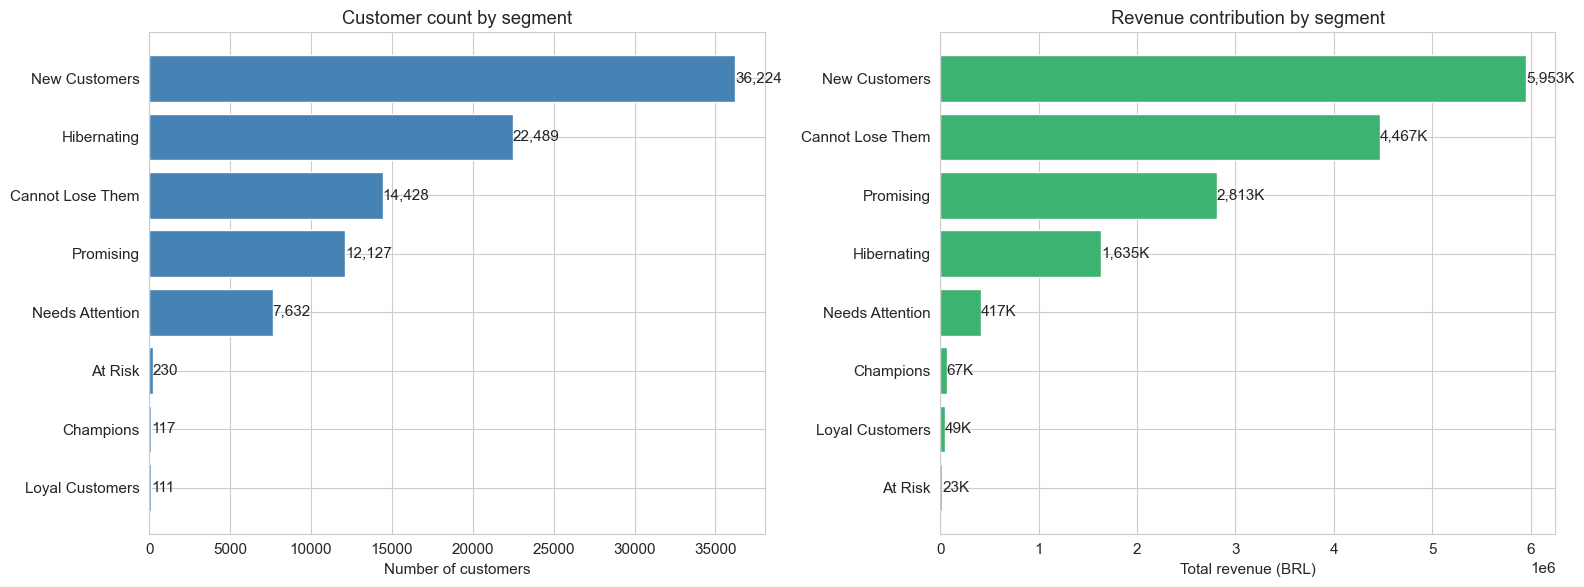

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_count = rfm['segment'].value_counts().sort_values()
axes[0].barh(seg_count.index, seg_count.values, color='steelblue')
axes[0].set_xlabel('Number of customers')
axes[0].set_title('Customer count by segment')
for i, v in enumerate(seg_count.values):
    axes[0].text(v, i, f'{v:,}', va='center')

seg_rev = rfm.groupby('segment')['monetary'].sum().sort_values()
axes[1].barh(seg_rev.index, seg_rev.values, color='mediumseagreen')
axes[1].set_xlabel('Total revenue (BRL)')
axes[1].set_title('Revenue contribution by segment')
for i, v in enumerate(seg_rev.values):
    axes[1].text(v, i, f'{v/1000:,.0f}K', va='center')

plt.tight_layout()
plt.show()

**Key RFM finding:** The "Cannot Lose Them" segment is the standout strategic asset, with 14,428 customers (15.5% of base) who historically drove 29% of marketplace revenue but have now gone dormant (average recency ~393 days). This is the largest single high-value pool that no one is currently engaging.

In [11]:
rfm.to_parquet('./data/processed/rfm_segments.parquet', index=False)
rfm.to_csv('./data/processed/rfm_segments.csv', index=False)

rfm.to_sql('dim_customer_rfm', engine, if_exists='replace', index=False, chunksize=5000)
print('RFM saved to disk and to MySQL as dim_customer_rfm')

RFM saved to disk and to MySQL as dim_customer_rfm


## Section 2: Historic CLV

Historic CLV is the total revenue each customer has generated to date, equivalent to the `monetary` value from the RFM table. We pair this with segment assignments to identify revenue concentration patterns.

No predictive CLV model is built since the structural single-purchase nature of the Olist customer base makes predictive modelling unproductive for this dataset. The historic view is sufficient for the recommendations. 

In [12]:
clv = rfm[['customer_unique_id', 'segment', 'monetary']].rename(columns={'monetary':'historic_clv'})

print('Historic CLV summary (BRL):')
print(clv['historic_clv'].describe().round(2))

percentiles = [50, 75, 90, 95, 99]
print('\nCLV thresholds at key percentiles:')
for p in percentiles:
    threshold = clv['historic_clv'].quantile(p/100)
    n_above = (clv['historic_clv'] >= threshold).sum()
    print(f'  Top {100 - p:>2}% threshold: {threshold:>8.2f} BRL  ({n_above:>6,} customers above)')

Historic CLV summary (BRL):
count    93358.00
mean       165.20
std        226.31
min          0.00
25%         63.05
50%        107.78
75%        182.56
max      13664.08
Name: historic_clv, dtype: float64

CLV thresholds at key percentiles:
  Top 50% threshold:   107.78 BRL  (46,782 customers above)
  Top 25% threshold:   182.56 BRL  (23,340 customers above)
  Top 10% threshold:   318.07 BRL  ( 9,336 customers above)
  Top  5% threshold:   469.62 BRL  ( 4,668 customers above)
  Top  1% threshold:  1097.06 BRL  (   934 customers above)


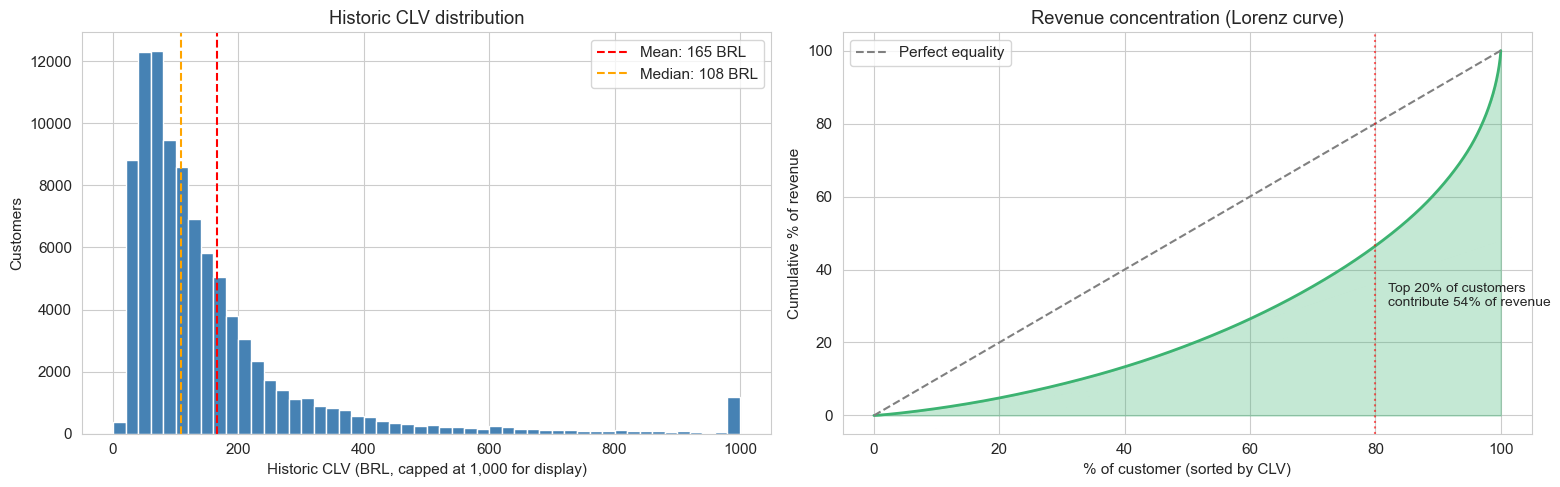

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LEFT: Histogram, capped at 1,000 BRL for readability.
# Values >1,000 (top ~1% of customers) are pinned to 1,000 to prevent the long tail.
# The mean and median lines reflect the true (uncapped) values.
axes[0].hist(clv['historic_clv'].clip(upper=1000), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(clv['historic_clv'].mean(), color='red', linestyle='--', 
                label=f'Mean: {clv['historic_clv'].mean():.0f} BRL')
axes[0].axvline(clv['historic_clv'].median(), color='orange', linestyle='--',
                label=f'Median: {clv['historic_clv'].median():.0f} BRL')
axes[0].set_xlabel('Historic CLV (BRL, capped at 1,000 for display)')
axes[0].set_ylabel('Customers')
axes[0].set_title('Historic CLV distribution')
axes[0].legend()

# RIGHT: Lorenz-style "cumulative revenue share" curve.
# x-axis: % of customers (sorted by CLV, lowest to highest)
# y-axis: cumulative % of total revenue they contribute
sorted_clv = clv['historic_clv'].sort_values().values
cum_pct_customers = np.arange(1, len(sorted_clv) +1) / len(sorted_clv) * 100
cum_pct_revenue = sorted_clv.cumsum() / sorted_clv.sum() * 100

axes[1].plot(cum_pct_customers, cum_pct_revenue, color='mediumseagreen', linewidth=2)
axes[1].plot([0, 100], [0, 100], color='gray', linestyle='--', label='Perfect equality')
axes[1].fill_between(cum_pct_customers, cum_pct_revenue, alpha=0.3, color='mediumseagreen')

# 80/20 inflection
top_20_threshold = np.percentile(sorted_clv, 80)
revenue_from_top_20 = sorted_clv[sorted_clv >= top_20_threshold].sum() / sorted_clv.sum() * 100
axes[1].axvline(80, color='red', linestyle=':', alpha=0.6)
axes[1].text(82, 30, f'Top 20% of customers\ncontribute {revenue_from_top_20:.0f}% of revenue', fontsize=10)

axes[1].set_xlabel('% of customer (sorted by CLV)')
axes[1].set_ylabel('Cumulative % of revenue')
axes[1].set_title('Revenue concentration (Lorenz curve)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Per-segment summary, sorted by total revenue contribution
segment_clv = clv.groupby('segment').agg(
    customers = ('customer_unique_id', 'count'),
    avg_clv = ('historic_clv', 'mean'),
    median_clv = ('historic_clv', 'median'),
    total_revenue = ('historic_clv', 'sum')).round(2)

segment_clv['pct_customers'] = (segment_clv['customers'] / segment_clv['customers'].sum() * 100).round(1)
segment_clv['pct_revenue'] = (segment_clv['total_revenue'] / segment_clv['total_revenue'].sum() * 100).round(1)

segment_clv['revenue_index'] = (segment_clv['pct_revenue'] / segment_clv['pct_customers']).round(2)

segment_clv = segment_clv.sort_values('total_revenue', ascending=False)

print(segment_clv)

                  customers  avg_clv  median_clv  total_revenue  \
segment                                                           
New Customers         36224   164.34      108.20     5953007.74   
Cannot Lose Them      14428   309.60      212.73     4466878.65   
Promising             12127   231.93      165.80     2812625.85   
Hibernating           22489    72.71       70.14     1635175.61   
Needs Attention        7632    54.60       55.00      416693.97   
Champions               117   572.57      439.39       66990.67   
Loyal Customers         111   437.46      310.86       48558.16   
At Risk                 230    97.96      102.20       22531.12   

                  pct_customers  pct_revenue  revenue_index  
segment                                                      
New Customers              38.8         38.6           0.99  
Cannot Lose Them           15.5         29.0           1.87  
Promising                  13.0         18.2           1.40  
Hibernating        

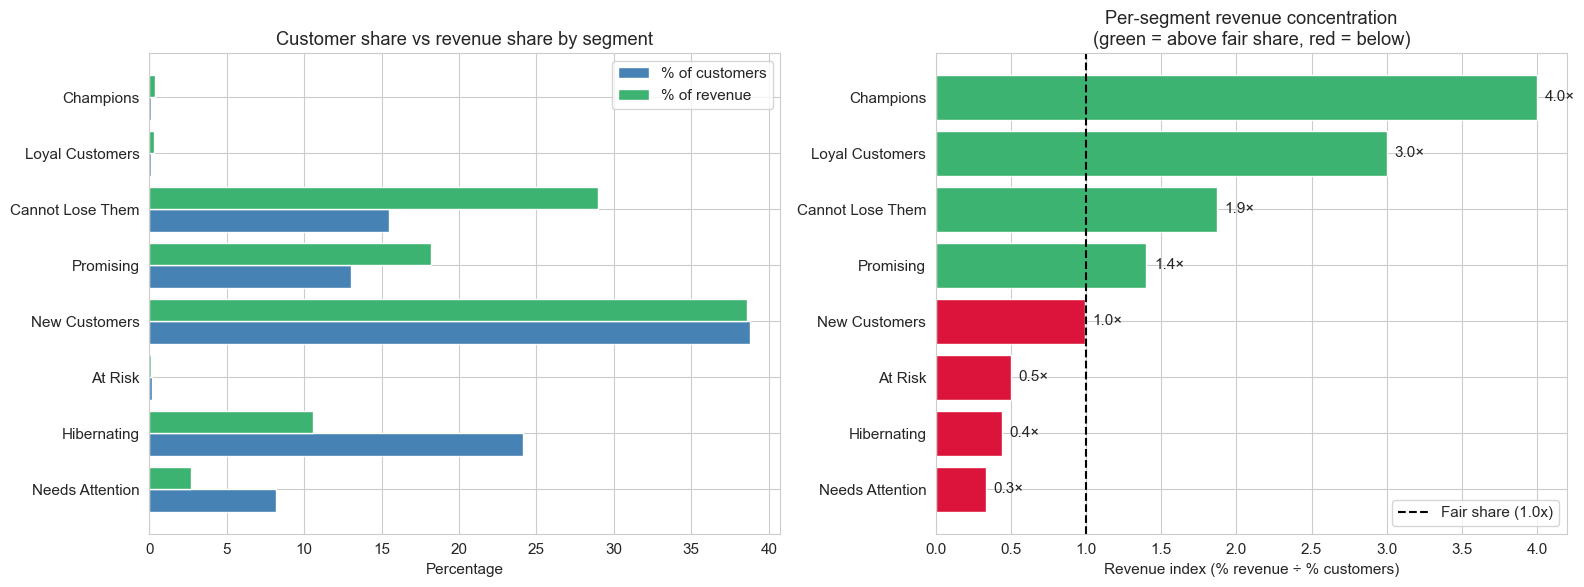

In [15]:
seg_for_chart = segment_clv.sort_values('revenue_index')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#LEFT: share of customers vs share of revenue
y_pos = np.arange(len(seg_for_chart))
width = 0.4
axes[0].barh(y_pos - width/2, seg_for_chart['pct_customers'], width, 
             label='% of customers', color='steelblue')
axes[0].barh(y_pos + width/2, seg_for_chart['pct_revenue'], width, 
             label='% of revenue', color='mediumseagreen')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(seg_for_chart.index)
axes[0].set_xlabel('Percentage')
axes[0].set_title('Customer share vs revenue share by segment')
axes[0].legend()

# RIGHT: Revenue index per segment
colors = ['crimson' if x < 1 else 'mediumseagreen' for x in seg_for_chart['revenue_index']]
axes[1].barh(seg_for_chart.index, seg_for_chart['revenue_index'], color=colors)
axes[1].axvline(1.0, color='black', linestyle='--', label='Fair share (1.0x)')
axes[1].set_xlabel('Revenue index (% revenue ÷ % customers)')
axes[1].set_title('Per-segment revenue concentration\n(green = above fair share, red = below)')
axes[1].legend()

for i, (idx, val) in enumerate(seg_for_chart['revenue_index'].items()):
    axes[1].text(val + 0.05, i, f'{val:.1f}×', va='center')

plt.tight_layout()
plt.show()

In [16]:
rfm_clv = rfm.merge(clv[['customer_unique_id', 'historic_clv']], on='customer_unique_id', how='left')

rfm_clv.to_parquet('./data/processed/rfm_clv.parquet', index=False)
rfm_clv.to_csv('./data/processed/rfm_clv.csv', index=False)

rfm_clv.to_sql('dim_customer_rfm_clv', engine, if_exists='replace', index=False, chunksize=5000)

segment_clv.reset_index().to_sql('agg_segment_clv', engine, if_exists='replace', index=False)

print(f'Saved rfm_clv ({len(rfm_clv):,} customer) to disk and MySQL.')
print(f'Saved segment_clv summary ({len(segment_clv)} segments) to MySQL.')

Saved rfm_clv (93,358 customer) to disk and MySQL.
Saved segment_clv summary (8 segments) to MySQL.


## Section 3: Cohort Retention

Cohort analysis groups customers by their first-purchase month and tracks whether they returned in subsequent months. The output is a 25x25 matrix (one row per acquisition month, one column per months-since-first). 

The key analytical question is whether Olist's low retention reflects declining customer satisfaction or structural marketplace dynamics. The answer (revealed below) shapes whether retention investments are worth making. 

In [17]:
first_purchase = order_level.groupby('customer_unique_id', as_index=False).agg(
    first_purchase_date=('order_date', 'min'))

first_purchase['cohort_month'] = first_purchase['first_purchase_date'].dt.to_period('M')

orders_with_cohort = order_level.merge(first_purchase, on='customer_unique_id')

orders_with_cohort['order_month'] = orders_with_cohort['order_date'].dt.to_period('M')
orders_with_cohort['months_since_first'] = (orders_with_cohort['order_month'].astype(int) - 
                                           orders_with_cohort['cohort_month'].astype(int))

print(orders_with_cohort[['customer_unique_id', 'cohort_month', 'order_month', 'months_since_first']].head())

print(f'\nNumber of cohorts: {orders_with_cohort['cohort_month'].nunique()}')
print(f'Months since first range: {orders_with_cohort['months_since_first'].min()} → {orders_with_cohort['months_since_first'].max()}')

                 customer_unique_id cohort_month order_month  \
0  871766c5855e863f6eccc05f988b23cb      2017-09     2017-09   
1  eb28e67c4c0b83846050ddfb8a35d051      2017-04     2017-04   
2  3818d81c6709e39d06b2738a8d3a2474      2018-01     2018-01   
3  af861d436cfc08b2c2ddefd0ba074622      2018-08     2018-08   
4  64b576fb70d441e8f1b2d7d446e483c5      2017-02     2017-02   

   months_since_first  
0                   0  
1                   0  
2                   0  
3                   0  
4                   0  

Number of cohorts: 23
Months since first range: 0 → 20


In [18]:
cohort_counts = orders_with_cohort.groupby(['cohort_month', 'months_since_first'])['customer_unique_id'].nunique().reset_index(name='active_customers')

cohort_matrix = cohort_counts.pivot(
    index = 'cohort_month',
    columns = 'months_since_first',
    values = 'active_customers')

cohort_sizes = cohort_matrix[0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0) * 100

print('Retention % (first 6 cohorts x first 12 months):')
print(retention_matrix.iloc[:6, :12].round(2))

Retention % (first 6 cohorts x first 12 months):
months_since_first     0       1     2     3     4     5     6     7     8   \
cohort_month                                                                  
2016-09             100.0     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2016-10             100.0     NaN   NaN   NaN   NaN   NaN  0.38   NaN   NaN   
2016-12             100.0  100.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2017-01             100.0    0.28  0.28  0.14  0.42  0.14  0.42  0.14  0.14   
2017-02             100.0    0.18  0.31  0.12  0.43  0.12  0.25  0.18  0.12   
2017-03             100.0    0.44  0.36  0.40  0.36  0.16  0.16  0.32  0.32   

months_since_first    9     10    11  
cohort_month                          
2016-09              NaN   NaN   NaN  
2016-10             0.38   NaN  0.38  
2016-12              NaN   NaN   NaN  
2017-01              NaN  0.42  0.14  
2017-02             0.18  0.12  0.31  
2017-03             0.08  0.36  0.12  


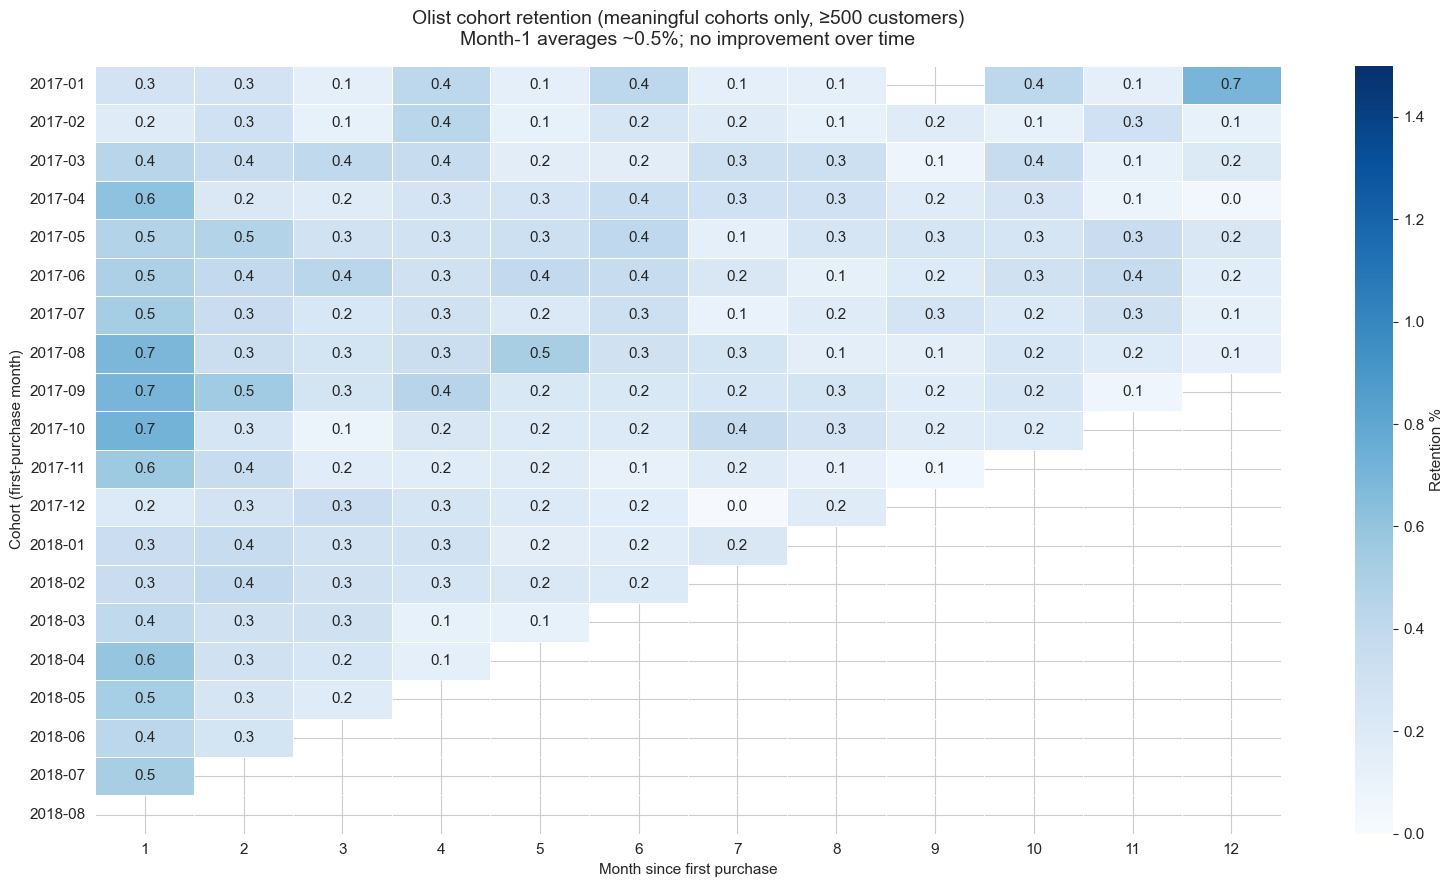

In [19]:
fig, ax = plt.subplots(figsize=(16, 9))

# Filter to cohorts with at least 500 first-time buyers - remove noisy early months
meaningful_cohorts = cohort_sizes[cohort_sizes >= 500].index
clean_matrix = retention_matrix.loc[meaningful_cohorts, :12].drop(columns=[0])
clean_matrix.index = clean_matrix.index.astype(str)

sns.heatmap(
    clean_matrix, 
    annot=True, 
    fmt='.1f',
    cmap='Blues',
    vmin=0, vmax=1.5, 
    cbar_kws={'label': 'Retention %'},
    linewidths=0.5,
    linecolor='white', 
    ax=ax)

ax.set_title('Olist cohort retention (meaningful cohorts only, ≥500 customers)\n'
             'Month-1 averages ~0.5%; no improvement over time', 
             fontsize=14, pad=15)
ax.set_xlabel('Month since first purchase')
ax.set_ylabel('Cohort (first-purchase month)')

plt.tight_layout()
plt.show()

In [20]:
meaningful_cohorts = cohort_sizes[cohort_sizes >= 500].index
clean_retention = retention_matrix.loc[meaningful_cohorts, :]
avg_retention = clean_retention.mean(axis=0)

print('Average retention across all cohorts (%):')
for period in [1, 3, 6, 12]:
    if period in avg_retention.index:
        val = avg_retention[period]
        if not pd.isna(val):
            print(f'  Month {period:>2}: {val:5.2f}%')

clean_with_period_1 = clean_retention.dropna(subset=[1])
early_meaningful = clean_with_period_1.iloc[:6, :][1].mean()
recent_meaningful = clean_with_period_1.iloc[-6:, :][1].mean()

print(f'\nMonth-1 retention - earliest 6 cohorts: {early_meaningful:.2f}%')
print(f'Month-1 retention - most recent 6 cohorts: {recent_meaningful:.2f}%')
print(f'Change: {recent_meaningful - early_meaningful:+.2f} percentage points')

Average retention across all cohorts (%):
  Month  1:  0.48%
  Month  3:  0.25%
  Month  6:  0.26%
  Month 12:  0.21%

Month-1 retention - earliest 6 cohorts: 0.41%
Month-1 retention - most recent 6 cohorts: 0.47%
Change: +0.05 percentage points


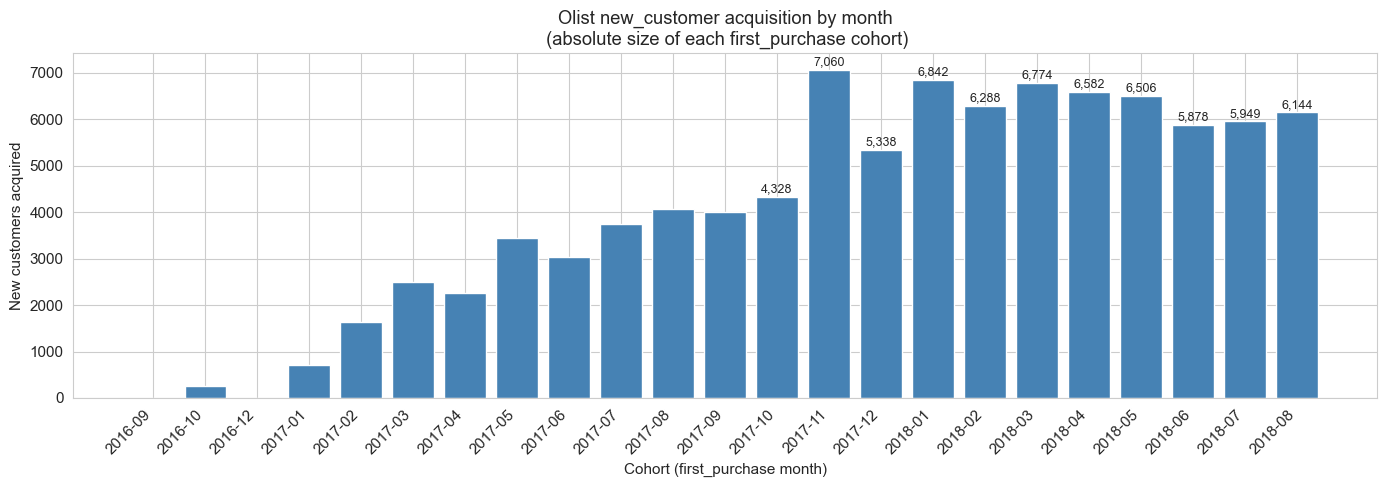


Total new customers acquired: 93,358
Largest single-month acquisition: 7,060 (in 2017-11)
Smallest single-month acquisition: 1 (in 2016-09)


In [21]:
fig, ax = plt.subplots(figsize=(14,5))

cohort_sizes_display = cohort_sizes.copy()
cohort_sizes_display.index = cohort_sizes_display.index.astype(str)

ax.bar(cohort_sizes_display.index, cohort_sizes_display.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Cohort (first_purchase month)')
ax.set_ylabel('New customers acquired')
ax.set_title('Olist new_customer acquisition by month\n'
             ' (absolute size of each first_purchase cohort)')

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(cohort_sizes_display.values):
    if v > cohort_sizes_display.values.mean():
        ax.text(i, v + 100, f'{int(v):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nTotal new customers acquired: {cohort_sizes_display.sum():,.0f}')
print(f'Largest single-month acquisition: {cohort_sizes_display.max():,.0f} '
      f'(in {cohort_sizes_display.idxmax()})')
print(f'Smallest single-month acquisition: {cohort_sizes_display.min():,.0f} '
      f'(in {cohort_sizes_display.idxmin()})')

In [22]:
retention_matrix.to_csv('./data/processed/cohort_retention.csv')

retention_matrix.reset_index().to_sql('agg_cohort_retention', engine, if_exists='replace', index=False)

cohort_sizes.reset_index(name='new_customers').to_sql('agg_cohort_sizes', engine, if_exists='replace', index=False)

print('Saved cohort retention matrix and cohort sizes to disk and MySQL')

Saved cohort retention matrix and cohort sizes to disk and MySQL


## Summary

Olist's customer base is acquisition-driven, not retention-driven:

- 99% of revenue comes from customers who purchase once
- Retention is structurally low (~0.5% month-1) and consistent across cohorts, not deteriorating
- The biggest commercial leverage in the customer base is the "Cannot Lose Them" segment with high historic value but currently dormant

These findings inform Recommendation 4 in the commercial memo (targeted reactivation of the Cannot Lose Them segment) and shape the overall acquisition-led growth thesis. 